In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import networkx as nx
import numpy as np
from scipy import stats

In [17]:
import folium

In [18]:
data = pd.read_csv('../../data/processed/fdemand.csv')

In [19]:
data_no3000 = data[data['end_station'] != 3000]

In [20]:
data_no3000.head()

,duration,start_station,end_station,plan_duration,st_year,st_month,st_day,st_hour,st_minute,end_year,...,end_name,end_lat,end_lon,dist_km,avg_wind,precip,snow,snow_ground,max_temp,min_temp
0,11,3049,3072,30,2020,1,1,0,13,2020,...,Front & Carpenter,39.93445,-75.14541,1.208846,9.17,0.0,0.0,0.0,42,29
1,28,3124,3053,30,2020,1,1,0,14,2020,...,Point Breeze & Tasker,39.93231,-75.18154,4.295275,9.17,0.0,0.0,0.0,42,29
2,28,3124,3053,30,2020,1,1,0,14,2020,...,Point Breeze & Tasker,39.93231,-75.18154,4.295275,9.17,0.0,0.0,0.0,42,29
3,21,3005,3018,30,2020,1,1,0,17,2020,...,12th & Filbert,39.95273,-75.15979,1.471505,9.17,0.0,0.0,0.0,42,29
4,21,3005,3018,30,2020,1,1,0,17,2020,...,12th & Filbert,39.95273,-75.15979,1.471505,9.17,0.0,0.0,0.0,42,29


In [39]:
data_no3000.dtypes

duration               int64
start_station          int64
end_station            int64
plan_duration          int64
st_year                int64
st_month               int64
st_day                 int64
st_hour                int64
st_minute              int64
end_year               int64
end_month              int64
end_day                int64
end_hour               int64
end_minute             int64
bike_electric          int64
pass_daypass           int64
pass_indego30          int64
pass_indego365         int64
pass_walkup            int64
trip_oneway            int64
day_of_week            int64
is_weekend             int64
st_hr_sin            float64
st_hr_cos            float64
st_day_sin           float64
st_day_cos           float64
st_yr_sin            float64
st_yr_cos            float64
in_deg_start         float64
out_deg_start        float64
betweenness_start    float64
closeness_start      float64
pagerank_start       float64
in_deg_end           float64
out_deg_end   

In [21]:
# Define all_station_coords_df_full
# Extract unique station coordinates from the main data
# We'll combine start and end station information to get a comprehensive list.

# Collect start station info (without 'start_name' as it's missing)
start_stations = data[['start_station', 'st_lat', 'st_lon']].drop_duplicates().copy()
start_stations.rename(columns={'start_station': 'station_id',
                               'st_lat': 'latitude',
                               'st_lon': 'longitude'}, inplace=True)
# Add a placeholder for station_name for start_stations
start_stations['station_name'] = None

# Collect end station info (with 'end_name')
end_stations = data[['end_station', 'end_lat', 'end_lon', 'end_name']].drop_duplicates().copy()
end_stations.rename(columns={'end_station': 'station_id',
                             'end_lat': 'latitude',
                             'end_lon': 'longitude',
                             'end_name': 'station_name'}, inplace=True)

# Combine and remove duplicates to get all unique station coordinates and names
# Use a common set of columns for concat to ensure they align
all_station_coords_df_full = pd.concat([start_stations[['station_id', 'latitude', 'longitude', 'station_name']],
                                        end_stations[['station_id', 'latitude', 'longitude', 'station_name']]]) \
                            .drop_duplicates(subset=['station_id']).reset_index(drop=True)

# Ensure station_id is integer type for consistent merging
all_station_coords_df_full['station_id'] = all_station_coords_df_full['station_id'].astype(int)


# Preprocessing: Calculate daily net change per station from data_no3000
# Ensure 'st_year', 'st_month', 'st_day' are used to create a date column
# This assumes data_no3000 contains 'start_station', 'end_station', 'st_year', 'st_month', 'st_day'

# Create a daily identifier
# Make a copy to avoid SettingWithCopyWarning
data_for_net_change = data_no3000.copy()
data_for_net_change['date'] = pd.to_datetime({'year': data_for_net_change['st_year'], 'month': data_for_net_change['st_month'], 'day': data_for_net_change['st_day']})

# Count bikes leaving each station per day
departures = data_for_net_change.groupby(['date', 'start_station']).size().reset_index(name='departures')
departures.rename(columns={'start_station': 'station_id'}, inplace=True)

# Count bikes arriving at each station per day
arrivals = data_for_net_change.groupby(['date', 'end_station']).size().reset_index(name='arrivals')
arrivals.rename(columns={'end_station': 'station_id'}, inplace=True)

# Merge departures and arrivals
daily_station_activity = pd.merge(departures, arrivals, on=['date', 'station_id'], how='outer').fillna(0)

# Calculate net change
daily_station_activity['net_change'] = daily_station_activity['arrivals'] - daily_station_activity['departures']

net_change_daily_df_no3000 = daily_station_activity


# 1. Calculate average daily net change for each station using the new data
average_net_change_per_station = net_change_daily_df_no3000.groupby('station_id')['net_change'].mean().reset_index()
average_net_change_per_station.rename(columns={'net_change': 'average_net_flow'}, inplace=True)

# 2. Calculate magnitude of imbalance (absolute average net flow)
average_net_change_per_station['imbalance_magnitude'] = average_net_change_per_station['average_net_flow'].abs()

# 3. Merge with station coordinates (using all_station_coords_df_full from previous cells)
stations_data_for_map = pd.merge(
    all_station_coords_df_full, # No need to reset_index if all_station_coords_df_full is already clean
    average_net_change_per_station,
    on='station_id',
    how='inner'
)

# Handle potential NaN values or missing coordinates
stations_data_for_map.dropna(subset=['latitude', 'longitude'], inplace=True)

# Fill missing station names (e.g., for start-only stations) with their ID
stations_data_for_map['station_name'] = stations_data_for_map.apply(
    lambda row: row['station_name'] if pd.notna(row['station_name']) else f"Station {int(row['station_id'])}",
    axis=1
)

# Create a base map centered around the average coordinates of these stations
map_center_lat = stations_data_for_map['latitude'].mean()
map_center_lon = stations_data_for_map['longitude'].mean()
m_imbalance = folium.Map(location=[map_center_lat, map_center_lon], zoom_start=12, control_scale=True)

# Scale marker size based on imbalance magnitude
# Normalize imbalance_magnitude for marker sizing: small values should be visible, large values not too big
max_imbalance = stations_data_for_map['imbalance_magnitude'].max()
min_imbalance = stations_data_for_map['imbalance_magnitude'].min()

def get_scaled_radius(magnitude, min_val, max_val):
    if max_val == min_val: # Avoid division by zero if all magnitudes are the same
        return 5
    # Scale between 3 and 20 for better visualization
    return 3 + (magnitude - min_val) / (max_val - min_val) * 17

# Add markers to the map
for idx, row in stations_data_for_map.iterrows():
    avg_net_flow = row['average_net_flow']
    imbalance_mag = row['imbalance_magnitude']
    station_id = row['station_id']
    station_name = row['station_name']

    # Assign color based on net change (green for surplus, red for deficit)
    if avg_net_flow > 0:
        marker_color = 'green' # Surplus
    elif avg_net_flow < 0:
        marker_color = 'red' # Deficit
    else:
        marker_color = 'gray' # Neutral (no net change)

    # Scale radius
    radius = get_scaled_radius(imbalance_mag, min_imbalance, max_imbalance)

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=radius,
        color=marker_color,
        fill=True,
        fill_color=marker_color,
        fill_opacity=0.8,
        popup=f"Station ID: {int(station_id)}<br>Name: {station_name}<br>Avg Net Flow: {avg_net_flow:.2f}<br>Imbalance Mag: {imbalance_mag:.2f}"
    ).add_to(m_imbalance)

In [22]:
m_imbalance

In [23]:
daily_station_activity.head()

,date,station_id,departures,arrivals,net_change
0,2020-01-01,3004,2.0,2.0,0.0
1,2020-01-01,3005,10.0,2.0,-8.0
2,2020-01-01,3006,3.0,4.0,1.0
3,2020-01-01,3007,3.0,7.0,4.0
4,2020-01-01,3008,1.0,1.0,0.0


### Daily Station Activity by 12-Hour Slots (7 AM - 7 PM and 7 PM - 7 AM)

this block is for 7am - 7pm slots

In [42]:
# Make a copy to avoid SettingWithCopyWarning and add a 'time_slot' column
data_for_slots7 = data_no3000.copy()
data_for_slots7['date'] = pd.to_datetime({'year': data_for_slots7['st_year'], 'month': data_for_slots7['st_month'], 'day': data_for_slots7['st_day']})

def get_time_slot(hour):
    if 7 <= hour < 19:
        return 'Day (7AM-7PM)'
    else:
        return 'Night (7PM-7AM)'

data_for_slots7['time_slot'] = data_for_slots7['st_hour'].apply(get_time_slot)

# Count departures per day, per station, per time slot
departures_by_slot = data_for_slots7.groupby(['date', 'start_station', 'time_slot']).size().reset_index(name='departures')
departures_by_slot.rename(columns={'start_station': 'station_id'}, inplace=True)

# Count arrivals per day, per station, per time slot
arrivals_by_slot = data_for_slots7.groupby(['date', 'end_station', 'time_slot']).size().reset_index(name='arrivals')
arrivals_by_slot.rename(columns={'end_station': 'station_id'}, inplace=True)

# Merge departures and arrivals by date, station_id, and time_slot
daily_station_activity_by_slot7 = pd.merge(
    departures_by_slot,
    arrivals_by_slot,
    on=['date', 'station_id', 'time_slot'],
    how='outer'
).fillna(0)

# Calculate net change for each slot
daily_station_activity_by_slot7['net_change'] = daily_station_activity_by_slot7['arrivals'] - daily_station_activity_by_slot7['departures']

display(daily_station_activity_by_slot7.head())


,date,station_id,time_slot,departures,arrivals,net_change
0,2020-01-01,3004,Day (7AM-7PM),1.0,1.0,0.0
1,2020-01-01,3004,Night (7PM-7AM),1.0,1.0,0.0
2,2020-01-01,3005,Day (7AM-7PM),2.0,1.0,-1.0
3,2020-01-01,3005,Night (7PM-7AM),8.0,1.0,-7.0
4,2020-01-01,3006,Day (7AM-7PM),1.0,3.0,2.0


this block for 12am - 12pm and 12pm - 12am slots

In [43]:
# Make a copy to avoid SettingWithCopyWarning and add a 'time_slot' column
data_for_slots12 = data_no3000.copy()
data_for_slots12['date'] = pd.to_datetime({'year': data_for_slots12['st_year'], 'month': data_for_slots12['st_month'], 'day': data_for_slots12['st_day']})

def get_time_slot(hour):
    if 0 <= hour < 12:
        return 'Day (12AM-12PM)'
    else:
        return 'Night (12PM-12AM)'

data_for_slots12['time_slot'] = data_for_slots12['st_hour'].apply(get_time_slot)

# Count departures per day, per station, per time slot
departures_by_slot = data_for_slots12.groupby(['date', 'start_station', 'time_slot']).size().reset_index(name='departures')
departures_by_slot.rename(columns={'start_station': 'station_id'}, inplace=True)

# Count arrivals per day, per station, per time slot
arrivals_by_slot = data_for_slots12.groupby(['date', 'end_station', 'time_slot']).size().reset_index(name='arrivals')
arrivals_by_slot.rename(columns={'end_station': 'station_id'}, inplace=True)

# Merge departures and arrivals by date, station_id, and time_slot
daily_station_activity_by_slot12 = pd.merge(
    departures_by_slot,
    arrivals_by_slot,
    on=['date', 'station_id', 'time_slot'],
    how='outer'
).fillna(0)

# Calculate net change for each slot
daily_station_activity_by_slot12['net_change'] = daily_station_activity_by_slot12['arrivals'] - daily_station_activity_by_slot12['departures']

display(daily_station_activity_by_slot12.head())

,date,station_id,time_slot,departures,arrivals,net_change
0,2020-01-01,3004,Day (12AM-12PM),2.0,1.0,-1.0
1,2020-01-01,3004,Night (12PM-12AM),0.0,1.0,1.0
2,2020-01-01,3005,Day (12AM-12PM),7.0,1.0,-6.0
3,2020-01-01,3005,Night (12PM-12AM),3.0,1.0,-2.0
4,2020-01-01,3006,Night (12PM-12AM),3.0,4.0,1.0


In [26]:
daily_station_activity.head()

,date,station_id,departures,arrivals,net_change
0,2020-01-01,3004,2.0,2.0,0.0
1,2020-01-01,3005,10.0,2.0,-8.0
2,2020-01-01,3006,3.0,4.0,1.0
3,2020-01-01,3007,3.0,7.0,4.0
4,2020-01-01,3008,1.0,1.0,0.0


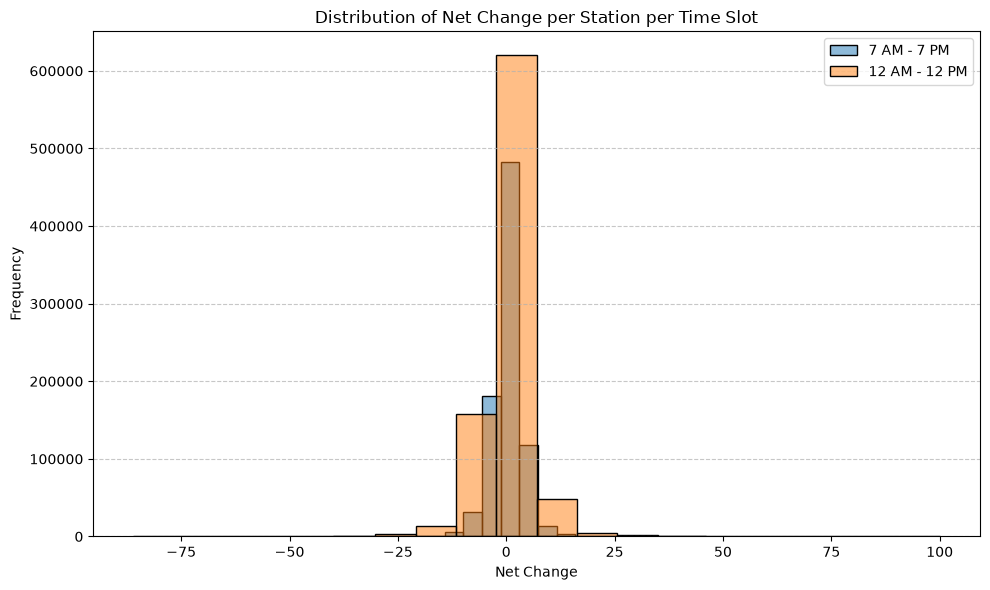

In [44]:
plt.figure(figsize=(10, 6))

sns.histplot(
    daily_station_activity_by_slot7['net_change'],
    bins=20,
    alpha=0.5,
    label='7 AM - 7 PM',
    stat='count'
)

sns.histplot(
    daily_station_activity_by_slot12['net_change'],
    bins=20,
    alpha=0.5,
    label='12 AM - 12 PM',
    stat='count'
)

plt.title('Distribution of Net Change per Station per Time Slot')
plt.xlabel('Net Change')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [28]:


# --- 1. Recalculate daily_station_activity_by_slot for 12 AM - 12 PM slots ---
# Ensure data_no3000 is available, which it is from previous cells.
# Make a copy to avoid SettingWithCopyWarning
data_for_slots_12h = data_no3000.copy()
data_for_slots_12h['date'] = pd.to_datetime({'year': data_for_slots_12h['st_year'], 'month': data_for_slots_12h['st_month'], 'day': data_for_slots_12h['st_day']})

def get_time_slot_12h(hour):
    if 0 <= hour < 12:
        return 'Day (12AM-12PM)'
    else:
        return 'Night (12PM-12AM)'

data_for_slots_12h['time_slot'] = data_for_slots_12h['st_hour'].apply(get_time_slot_12h)

# Count departures per day, per station, per time slot
departures_by_slot_12h = data_for_slots_12h.groupby(['date', 'start_station', 'time_slot']).size().reset_index(name='departures')
departures_by_slot_12h.rename(columns={'start_station': 'station_id'}, inplace=True)

# Count arrivals per day, per station, per time slot
arrivals_by_slot_12h = data_for_slots_12h.groupby(['date', 'end_station', 'time_slot']).size().reset_index(name='arrivals')
arrivals_by_slot_12h.rename(columns={'end_station': 'station_id'}, inplace=True)

# Merge departures and arrivals by date, station_id, and time_slot
daily_station_activity_by_slot_12h = pd.merge(
    departures_by_slot_12h,
    arrivals_by_slot_12h,
    on=['date', 'station_id', 'time_slot'],
    how='outer'
).fillna(0)

# Calculate net change for each slot
daily_station_activity_by_slot_12h['net_change'] = daily_station_activity_by_slot_12h['arrivals'] - daily_station_activity_by_slot_12h['departures']


# --- 2. Recalculate daily_station_activity_by_slot for 7 AM - 7 PM slots (if not already correctly stored) ---
# Make a copy to avoid SettingWithCopyWarning
data_for_slots_7h = data_no3000.copy()
data_for_slots_7h['date'] = pd.to_datetime({'year': data_for_slots_7h['st_year'], 'month': data_for_slots_7h['st_month'], 'day': data_for_slots_7h['st_day']})

def get_time_slot_7h(hour):
    if 7 <= hour < 19:
        return 'Day (7AM-7PM)'
    else:
        return 'Night (7PM-7AM)'

data_for_slots_7h['time_slot'] = data_for_slots_7h['st_hour'].apply(get_time_slot_7h)

# Count departures per day, per station, per time slot
departures_by_slot_7h = data_for_slots_7h.groupby(['date', 'start_station', 'time_slot']).size().reset_index(name='departures')
departures_by_slot_7h.rename(columns={'start_station': 'station_id'}, inplace=True)

# Count arrivals per day, per station, per time slot
arrivals_by_slot_7h = data_for_slots_7h.groupby(['date', 'end_station', 'time_slot']).size().reset_index(name='arrivals')
arrivals_by_slot_7h.rename(columns={'end_station': 'station_id'}, inplace=True)

# Merge departures and arrivals by date, station_id, and time_slot
daily_station_activity_by_slot_7h = pd.merge(
    departures_by_slot_7h,
    arrivals_by_slot_7h,
    on=['date', 'station_id', 'time_slot'],
    how='outer'
).fillna(0)

# Calculate net change for each slot
daily_station_activity_by_slot_7h['net_change'] = daily_station_activity_by_slot_7h['arrivals'] - daily_station_activity_by_slot_7h['departures']


# --- 3. Prepare data for paired t-test ---
# Filter for the specific 'Day' time slots from each dataset
net_change_12am_12pm = daily_station_activity_by_slot_12h[
    daily_station_activity_by_slot_12h['time_slot'] == 'Day (12AM-12PM)'
].set_index(['date', 'station_id'])[['net_change']]

net_change_7am_7pm = daily_station_activity_by_slot_7h[
    daily_station_activity_by_slot_7h['time_slot'] == 'Day (7AM-7PM)'
].set_index(['date', 'station_id'])[['net_change']]

# Merge the two datasets on 'date' and 'station_id' to create paired samples
paired_data = pd.merge(
    net_change_12am_12pm,
    net_change_7am_7pm,
    left_index=True, right_index=True,
    suffixes=('_12h', '_7h'),
    how='inner' # Only include pairs where both slots have data
).reset_index()

# --- 4. Perform paired t-test ---
# Drop rows where net_change might be NaN after merge (though 'inner' should prevent this for the compared columns)
paried_data_cleaned = paired_data.dropna(subset=['net_change_12h', 'net_change_7h'])

if not paried_data_cleaned.empty:
    t_statistic, p_value = stats.ttest_rel(paried_data_cleaned['net_change_12h'], paried_data_cleaned['net_change_7h'])

    print("\n--- Paired t-test results ---")
    print(f"Comparing: Net Change in 'Day (12AM-12PM)' vs 'Day (7AM-7PM)'")
    print(f"T-statistic: {t_statistic:.3f}")
    print(f"P-value: {p_value:.3f}")

    # Interpret the result
    alpha = 0.05 # Significance level
    if p_value < alpha:
        print("Conclusion: Reject the null hypothesis. There is a statistically significant difference between the net change in 'Day (12AM-12PM)' and 'Day (7AM-7PM)' time slots.")
    else:
        print("Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference between the net change in 'Day (12AM-12PM)' and 'Day (7AM-7PM)' time slots.")
else:
    print("Could not perform t-test: No common data points found for pairing between the two time slots.")



--- Paired t-test results ---
Comparing: Net Change in 'Day (12AM-12PM)' vs 'Day (7AM-7PM)'
T-statistic: 0.300
P-value: 0.764
Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference between the net change in 'Day (12AM-12PM)' and 'Day (7AM-7PM)' time slots.


In [29]:
data_no3000.head()

,duration,start_station,end_station,plan_duration,st_year,st_month,st_day,st_hour,st_minute,end_year,...,end_name,end_lat,end_lon,dist_km,avg_wind,precip,snow,snow_ground,max_temp,min_temp
0,11,3049,3072,30,2020,1,1,0,13,2020,...,Front & Carpenter,39.93445,-75.14541,1.208846,9.17,0.0,0.0,0.0,42,29
1,28,3124,3053,30,2020,1,1,0,14,2020,...,Point Breeze & Tasker,39.93231,-75.18154,4.295275,9.17,0.0,0.0,0.0,42,29
2,28,3124,3053,30,2020,1,1,0,14,2020,...,Point Breeze & Tasker,39.93231,-75.18154,4.295275,9.17,0.0,0.0,0.0,42,29
3,21,3005,3018,30,2020,1,1,0,17,2020,...,12th & Filbert,39.95273,-75.15979,1.471505,9.17,0.0,0.0,0.0,42,29
4,21,3005,3018,30,2020,1,1,0,17,2020,...,12th & Filbert,39.95273,-75.15979,1.471505,9.17,0.0,0.0,0.0,42,29


###### models

In [30]:


# 1. Create a directed graph representing the bike-sharing network
G = nx.DiGraph()

# Add all unique stations as nodes
all_unique_stations = pd.concat([data_no3000['start_station'], data_no3000['end_station']]).unique()
G.add_nodes_from(all_unique_stations)

# Add edges with weights (number of trips) between start and end stations
trip_counts = data_no3000.groupby(['start_station', 'end_station']).size().reset_index(name='trip_count')

for _, row in trip_counts.iterrows():
    G.add_edge(row['start_station'], row['end_station'], weight=row['trip_count'])

# 2. Calculate Centrality Measures
centrality_measures = {
    'station_id': [],
    'degree_centrality_in': [],
    'degree_centrality_out': [],
    'betweenness_centrality_unweighted': [],
    'closeness_centrality_unweighted': [],
    'eigenvector_centrality_weighted': []
}

in_degree_centrality = nx.in_degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)

# Use unweighted centrality for betweenness and closeness for a standard interpretation of 'paths'
betweenness_unweighted = nx.betweenness_centrality(G)
closeness_unweighted = nx.closeness_centrality(G)

# Use weighted eigenvector centrality, where higher trip count means more influence
try:
    eigenvector_weighted = nx.eigenvector_centrality(G, weight='weight', max_iter=1000, tol=1e-06)
except nx.PowerIterationFailedConvergence:
    print("Eigenvector centrality did not converge for some nodes. Assigning 0 to non-converged nodes.")
    eigenvector_weighted = {node: 0 for node in G.nodes()}
except Exception as e:
    print(f"Error calculating eigenvector centrality: {e}. Assigning 0 to all nodes.")
    eigenvector_weighted = {node: 0 for node in G.nodes()}

for station_id in G.nodes():
    centrality_measures['station_id'].append(station_id)
    centrality_measures['degree_centrality_in'].append(in_degree_centrality.get(station_id, 0))
    centrality_measures['degree_centrality_out'].append(out_degree_centrality.get(station_id, 0))
    centrality_measures['betweenness_centrality_unweighted'].append(betweenness_unweighted.get(station_id, 0))
    centrality_measures['closeness_centrality_unweighted'].append(closeness_unweighted.get(station_id, 0))
    centrality_measures['eigenvector_centrality_weighted'].append(eigenvector_weighted.get(station_id, 0))

station_centrality_df = pd.DataFrame(centrality_measures)

# 3. Prepare base DataFrame for modeling: `daily_station_activity`
# This DataFrame contains 'date', 'station_id', 'departures', 'arrivals', 'net_change'
modeling_df = daily_station_activity.copy()

# 4. Add Time-based Features
modeling_df['weekday'] = modeling_df['date'].dt.weekday # Monday=0, Sunday=6
modeling_df['dayofyear'] = modeling_df['date'].dt.dayofyear
modeling_df['month'] = modeling_df['date'].dt.month
modeling_df['is_weekend'] = modeling_df['date'].dt.weekday.isin([5, 6])

# 5. Aggregate Daily Weather Data
# Create a 'date' column in data_no3000 to merge with modeling_df
weather_data_temp = data_no3000.copy()
weather_data_temp['date'] = pd.to_datetime({'year': weather_data_temp['st_year'], 'month': weather_data_temp['st_month'], 'day': weather_data_temp['st_day']})

weather_features = weather_data_temp.groupby('date')[['avg_wind', 'precip', 'snow', 'snow_ground', 'max_temp', 'min_temp']].mean().reset_index()

# 6. Merge all features into the modeling_df
# Merge centrality measures
modeling_df = pd.merge(modeling_df, station_centrality_df, on='station_id', how='left')

# Merge weather features
modeling_df = pd.merge(modeling_df, weather_features, on='date', how='left')

# Handle potential NaNs after merging
# Fill centrality NaNs with 0 (e.g., if a station existed in daily_station_activity but not in the graph)
centrality_cols = [col for col in station_centrality_df.columns if col != 'station_id']
for col in centrality_cols:
    modeling_df[col] = modeling_df[col].fillna(0)

# Fill weather NaNs, assuming weather features are generally available. Forward fill, then fill remaining with 0 or mean.
modeling_df.sort_values(by=['date', 'station_id'], inplace=True)
modeling_df[weather_features.columns.drop('date')] = modeling_df[weather_features.columns.drop('date')].ffill()
# Fill any remaining NaNs at the beginning of the series or if ffill couldn't propagate
modeling_df[weather_features.columns.drop('date')] = modeling_df[weather_features.columns.drop('date')].fillna(0)





Prepared dataset for XGBoost model (first 5 rows):


,date,station_id,departures,arrivals,net_change,weekday,dayofyear,month,is_weekend,degree_centrality_in,degree_centrality_out,betweenness_centrality_unweighted,closeness_centrality_unweighted,eigenvector_centrality_weighted,avg_wind,precip,snow,snow_ground,max_temp,min_temp
0,2020-01-01,3004,2.0,2.0,0.0,2,1,1,False,0.610465,0.607558,0.000245,0.714643,0.022472,9.17,0.0,0.0,0.0,42.0,29.0
1,2020-01-01,3005,10.0,2.0,-8.0,2,1,1,False,0.834302,0.834302,0.001171,0.853601,0.051949,9.17,0.0,0.0,0.0,42.0,29.0
2,2020-01-01,3006,3.0,4.0,1.0,2,1,1,False,0.857558,0.845930,0.002645,0.871201,0.066821,9.17,0.0,0.0,0.0,42.0,29.0
3,2020-01-01,3007,3.0,7.0,4.0,2,1,1,False,0.886628,0.895349,0.002138,0.894249,0.172888,9.17,0.0,0.0,0.0,42.0,29.0
4,2020-01-01,3008,1.0,1.0,0.0,2,1,1,False,0.694767,0.764535,0.001102,0.761320,0.010123,9.17,0.0,0.0,0.0,42.0,29.0



Information about the prepared dataset:
<class 'pandas.DataFrame'>
RangeIndex: 449633 entries, 0 to 449632
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   date                               449633 non-null  datetime64[us]
 1   station_id                         449633 non-null  int64         
 2   departures                         449633 non-null  float64       
 3   arrivals                           449633 non-null  float64       
 4   net_change                         449633 non-null  float64       
 5   weekday                            449633 non-null  int32         
 6   dayofyear                          449633 non-null  int32         
 7   month                              449633 non-null  int32         
 8   is_weekend                         449633 non-null  bool          
 9   degree_centrality_in               449633 non-null  float64   

In [ ]:
# Display the head and info of the prepared dataset
print("Prepared dataset for XGBoost model (first 5 rows):")
display(modeling_df.head())

In [ ]:
print("\nInformation about the prepared dataset:")
modeling_df.info()

In [31]:

# Define features (X) and target (y)
# Drop 'date', 'departures', 'arrivals' as 'net_change' is derived from them and 'date' is encoded into other features.
features = modeling_df.drop(columns=['date', 'departures', 'arrivals', 'net_change', 'station_id'])
target = modeling_df['net_change']

# Convert boolean 'is_weekend' to int for XGBoost compatibility
features['is_weekend'] = features['is_weekend'].astype(int)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Initialize and train the XGBoost Regressor model
# Using default parameters for a quick initial model
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', # For regression tasks
    n_estimators=100,             # Number of boosting rounds
    learning_rate=0.1,            # Step size shrinkage to prevent overfitting
    random_state=42
)

print("\nTraining XGBoost model...")
xgb_model.fit(X_train, y_train)
print("XGBoost model training complete.")

# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- XGBoost Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"R-squared (R2): {r2:.3f}")

# Display feature importance
print("\n--- Feature Importance ---")
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)
display(feature_importances.head(10))

X_train shape: (359706, 15)
X_test shape: (89927, 15)
y_train shape: (359706,)
y_test shape: (89927,)

Training XGBoost model...
XGBoost model training complete.

--- XGBoost Model Performance ---
Mean Absolute Error (MAE): 2.506
R-squared (R2): 0.050

--- Feature Importance ---


,feature,importance
5,degree_centrality_out,0.214458
8,eigenvector_centrality_weighted,0.160094
6,betweenness_centrality_unweighted,0.142355
0,weekday,0.106208
4,degree_centrality_in,0.093231
2,month,0.048203
13,max_temp,0.041994
10,precip,0.036919
14,min_temp,0.036854
1,dayofyear,0.035664


#### no models

In [32]:
# Create the 'is_round_trip' column on an explicit copy of the DataFrame to prevent SettingWithCopyWarning
data_no3000 = data_no3000.copy()
data_no3000['is_round_trip'] = (data_no3000['start_station'] == data_no3000['end_station'])

# Display the head with the new column
print("DataFrame head with 'is_round_trip' column:")
display(data_no3000.head())

# Display the count of round trips
round_trip_count = data_no3000['is_round_trip'].sum()
print(f"\nTotal number of round trips: {round_trip_count}")

DataFrame head with 'is_round_trip' column:


,duration,start_station,end_station,plan_duration,st_year,st_month,st_day,st_hour,st_minute,end_year,...,end_lat,end_lon,dist_km,avg_wind,precip,snow,snow_ground,max_temp,min_temp,is_round_trip
0,11,3049,3072,30,2020,1,1,0,13,2020,...,39.93445,-75.14541,1.208846,9.17,0.0,0.0,0.0,42,29,False
1,28,3124,3053,30,2020,1,1,0,14,2020,...,39.93231,-75.18154,4.295275,9.17,0.0,0.0,0.0,42,29,False
2,28,3124,3053,30,2020,1,1,0,14,2020,...,39.93231,-75.18154,4.295275,9.17,0.0,0.0,0.0,42,29,False
3,21,3005,3018,30,2020,1,1,0,17,2020,...,39.95273,-75.15979,1.471505,9.17,0.0,0.0,0.0,42,29,False
4,21,3005,3018,30,2020,1,1,0,17,2020,...,39.95273,-75.15979,1.471505,9.17,0.0,0.0,0.0,42,29,False



Total number of round trips: 332637


C:\Users\davel\AppData\Local\Temp\ipykernel_30648\3825438868.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hour', y='count', data=round_trips_by_hour, palette='viridis')


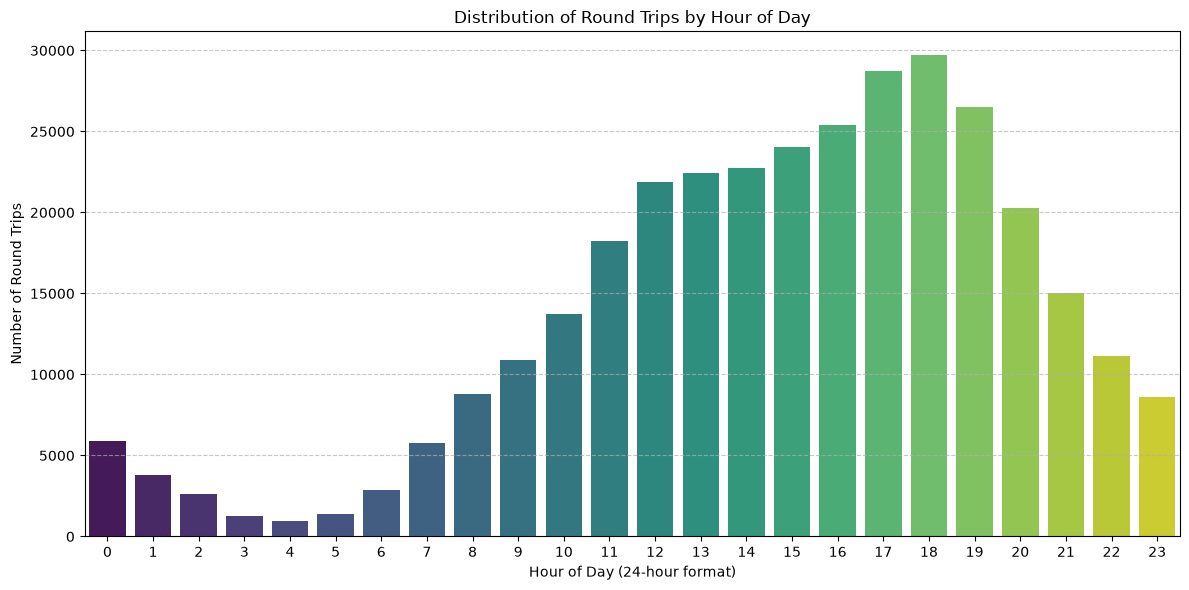


Number of round trips per hour:


,hour,count
0,0,5870
1,1,3783
2,2,2607
3,3,1273
4,4,938
5,5,1405
6,6,2855
7,7,5752
8,8,8801
9,9,10923


In [33]:


# Filter for round trips
round_trips_df = data_no3000[data_no3000['is_round_trip'] == True].copy()

# Get the hour of the day for round trips
# 'st_hour' column already contains the hour, so we can directly use it.
round_trips_by_hour = round_trips_df['st_hour'].value_counts().sort_index().reset_index()
round_trips_by_hour.columns = ['hour', 'count']

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='hour', y='count', data=round_trips_by_hour, palette='viridis')
plt.title('Distribution of Round Trips by Hour of Day')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Round Trips')
plt.xticks(range(0, 24)) # Ensure all hours from 0 to 23 are displayed
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



In [ ]:
# Display the aggregated data for round trips by hour
print("\nNumber of round trips per hour:")
display(round_trips_by_hour)

round trip analysis

In [35]:
# Filter for round trips
round_trips_only = data_no3000[data_no3000['is_round_trip'] == True].copy()

# Group by start_station (which is also the end_station for round trips) and count the number of round trips
round_trips_by_station = round_trips_only.groupby('start_station').size().reset_index(name='num_round_trips')
round_trips_by_station.rename(columns={'start_station': 'station_id'}, inplace=True)

# Filter for stations with more than 40 round trips
high_round_trip_stations = round_trips_by_station[round_trips_by_station['num_round_trips'] > 2000]

print("Stations with more than 2000 round trips:")
display(high_round_trip_stations.head())

# Merge with station coordinates (from all_station_coords_df_full)
stations_for_round_trip_map = pd.merge(
    high_round_trip_stations,
    all_station_coords_df_full, # This DataFrame contains latitude, longitude, and station_name
    on='station_id',
    how='inner'
)

# Drop rows with missing latitude or longitude
stations_for_round_trip_map.dropna(subset=['latitude', 'longitude'], inplace=True)

# Fill missing station names (e.g., for start-only stations) with their ID
stations_for_round_trip_map['station_name'] = stations_for_round_trip_map.apply(
    lambda row: row['station_name'] if pd.notna(row['station_name']) else f"Station {int(row['station_id'])}",
    axis=1
)

print("\nData for mapping high round trip stations:")
display(stations_for_round_trip_map.head())

Stations with more than 2000 round trips:


,station_id,num_round_trips
2,3006,2473
3,3007,2771
6,3010,3793
8,3012,2077
14,3018,2240



Data for mapping high round trip stations:


,station_id,num_round_trips,latitude,longitude,station_name
0,3006,2473,39.95220,-75.20311,Station 3006
1,3007,2771,39.94517,-75.15993,Station 3007
2,3010,3793,39.94711,-75.16618,Station 3010
3,3012,2077,39.94218,-75.17747,Station 3012
4,3018,2240,39.95273,-75.15979,Station 3018


In [38]:
stations_for_round_trip_map.head()

,station_id,num_round_trips,latitude,longitude,station_name
0,3006,2473,39.95220,-75.20311,Station 3006
1,3007,2771,39.94517,-75.15993,Station 3007
2,3010,3793,39.94711,-75.16618,Station 3010
3,3012,2077,39.94218,-75.17747,Station 3012
4,3018,2240,39.95273,-75.15979,Station 3018


In [37]:
# Create a base map centered around the average coordinates of these high round trip stations
if not stations_for_round_trip_map.empty:
    map_center_lat_rt = stations_for_round_trip_map['latitude'].mean()
    map_center_lon_rt = stations_for_round_trip_map['longitude'].mean()
    m_round_trips = folium.Map(location=[map_center_lat_rt, map_center_lon_rt], zoom_start=12, control_scale=True)

    # Scale marker size based on the number of round trips
    max_round_trips = stations_for_round_trip_map['num_round_trips'].max()
    min_round_trips = stations_for_round_trip_map['num_round_trips'].min()

    def get_scaled_radius_rt(count, min_val, max_val):
        if max_val == min_val: # Avoid division by zero if all counts are the same
            return 8 # Default size if no variation
        # Scale between 5 and 25 for better visualization
        return 5 + ((count - min_val) / (max_val - min_val)) * 20

    # Add markers to the map
    for idx, row in stations_for_round_trip_map.iterrows():
        station_id = row['station_id']
        station_name = row['station_name']
        num_round_trips = row['num_round_trips']

        radius_rt = get_scaled_radius_rt(num_round_trips, min_round_trips, max_round_trips)

        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=radius_rt,
            color='black',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6,
            popup=f"Station ID: {int(station_id)}<br>Name: {station_name}<br>Round Trips: {num_round_trips}"
        ).add_to(m_round_trips)

    display(m_round_trips)
else:
    print("No stations found with more than 40 round trips to display on the map.")

Mapping Average Imbalance for Original `data` vs. `data_no3000`

In [40]:


# Preprocessing: Calculate daily net change per station from the ORIGINAL `data`
# Create a daily identifier
data_for_net_change_original = data.copy()
data_for_net_change_original['date'] = pd.to_datetime({'year': data_for_net_change_original['st_year'], 'month': data_for_net_change_original['st_month'], 'day': data_for_net_change_original['st_day']})

# Count bikes leaving each station per day
departures_original = data_for_net_change_original.groupby(['date', 'start_station']).size().reset_index(name='departures')
departures_original.rename(columns={'start_station': 'station_id'}, inplace=True)

# Count bikes arriving at each station per day
arrivals_original = data_for_net_change_original.groupby(['date', 'end_station']).size().reset_index(name='arrivals')
arrivals_original.rename(columns={'end_station': 'station_id'}, inplace=True)

# Merge departures and arrivals
daily_station_activity_original = pd.merge(departures_original, arrivals_original, on=['date', 'station_id'], how='outer').fillna(0)

# Calculate net change
daily_station_activity_original['net_change'] = daily_station_activity_original['arrivals'] - daily_station_activity_original['departures']

# 1. Calculate average daily net change for each station
average_net_change_per_station_original = daily_station_activity_original.groupby('station_id')['net_change'].mean().reset_index()
average_net_change_per_station_original.rename(columns={'net_change': 'average_net_flow'}, inplace=True)

# 2. Calculate magnitude of imbalance (absolute average net flow)
average_net_change_per_station_original['imbalance_magnitude'] = average_net_change_per_station_original['average_net_flow'].abs()

# 3. Merge with station coordinates
stations_data_for_map_original = pd.merge(
    all_station_coords_df_full,
    average_net_change_per_station_original,
    on='station_id',
    how='inner'
)

# Handle potential NaN values or missing coordinates
stations_data_for_map_original.dropna(subset=['latitude', 'longitude'], inplace=True)

# Fill missing station names
stations_data_for_map_original['station_name'] = stations_data_for_map_original.apply(
    lambda row: row['station_name'] if pd.notna(row['station_name']) else f"Station {int(row['station_id'])}",
    axis=1
)

print("Data for mapping original `data` imbalance (first 5 rows):")
display(stations_data_for_map_original.head())





Data for mapping original `data` imbalance (first 5 rows):


,station_id,latitude,longitude,station_name,average_net_flow,imbalance_magnitude
0,3049,39.94509,-75.14250,Station 3049,0.328755,0.328755
1,3124,39.95367,-75.13956,Station 3124,0.237628,0.237628
2,3005,39.94733,-75.14403,Station 3005,0.103249,0.103249
3,3208,39.95048,-75.19324,Station 3208,0.884700,0.884700
4,3047,39.95073,-75.14947,Station 3047,-0.381521,0.381521


In [41]:
# Create a base map centered around the average coordinates of these stations
map_center_lat_original = stations_data_for_map_original['latitude'].mean()
map_center_lon_original = stations_data_for_map_original['longitude'].mean()
m_imbalance_original = folium.Map(location=[map_center_lat_original, map_center_lon_original], zoom_start=12, control_scale=True)

# Scale marker size based on imbalance magnitude
max_imbalance_original = stations_data_for_map_original['imbalance_magnitude'].max()
min_imbalance_original = stations_data_for_map_original['imbalance_magnitude'].min()

def get_scaled_radius(magnitude, min_val, max_val):
    if max_val == min_val:
        return 5
    return 3 + (magnitude - min_val) / (max_val - min_val) * 17

# Add markers to the map
for idx, row in stations_data_for_map_original.iterrows():
    avg_net_flow = row['average_net_flow']
    imbalance_mag = row['imbalance_magnitude']
    station_id = row['station_id']
    station_name = row['station_name']

    # Assign color based on net change
    if avg_net_flow > 0:
        marker_color = 'green'
    elif avg_net_flow < 0:
        marker_color = 'red'
    else:
        marker_color = 'gray'

    radius = get_scaled_radius(imbalance_mag, min_imbalance_original, max_imbalance_original)

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=radius,
        color=marker_color,
        fill=True,
        fill_color=marker_color,
        fill_opacity=0.8,
        popup=f"Station ID: {int(station_id)}<br>Name: {station_name}<br>Avg Net Flow: {avg_net_flow:.2f}<br>Imbalance Mag: {imbalance_mag:.2f}"
    ).add_to(m_imbalance_original)

print("\n--- Imbalance Map for Original `data` ---")
display(m_imbalance_original)

print("\n--- Imbalance Map for `data_no3000` (previously generated) ---")
display(m_imbalance)


--- Imbalance Map for Original `data` ---



--- Imbalance Map for `data_no3000` (previously generated) ---


poisson models fro predicting departure and arrivals

In [46]:
# Prepare features (X) and target (y)
# Features for Poisson model should be the same as for XGBoost, excluding original targets and identifiers
features_poisson = modeling_df.drop(columns=['date', 'departures', 'arrivals', 'net_change', 'station_id'])
features_poisson['is_weekend'] = features_poisson['is_weekend'].astype(int)

In [53]:


# --- Poisson Model for Arrivals ---
print("\n--- Poisson Regression Model for Arrivals ---")

target_arrivals = modeling_df['arrivals']

# Split data for Arrivals model
X_train_arrivals, X_test_arrivals, y_train_arrivals, y_test_arrivals = train_test_split(
    features_poisson, target_arrivals, test_size=0.2, random_state=42
)

# Ensure target is integer type for Poisson regression
y_train_arrivals = y_train_arrivals.astype(int)
y_test_arrivals = y_test_arrivals.astype(int)

# Add a constant to the features for the intercept term
X_train_arrivals_sm = sm.add_constant(X_train_arrivals)
X_test_arrivals_sm = sm.add_constant(X_test_arrivals)


--- Poisson Regression Model for Arrivals ---


In [54]:
# Fit the Poisson model
poisson_arrivals_model = sm.GLM(y_train_arrivals, X_train_arrivals_sm, family=sm.families.Poisson()).fit()
print(poisson_arrivals_model.summary())

# Make predictions
y_pred_arrivals_poisson = poisson_arrivals_model.predict(X_test_arrivals_sm)

# Evaluate the model (predictions are already non-negative and can be rounded to integers for MAE/R2)
y_pred_arrivals_poisson_rounded = np.round(y_pred_arrivals_poisson)

mae_arrivals_poisson = mean_absolute_error(y_test_arrivals, y_pred_arrivals_poisson_rounded)
r2_arrivals_poisson = r2_score(y_test_arrivals, y_pred_arrivals_poisson_rounded)

print(f"\nPoisson Model Performance (Arrivals - Rounded Predictions):\n  Mean Absolute Error (MAE): {mae_arrivals_poisson:.3f}\n  R-squared (R2): {r2_arrivals_poisson:.3f}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:               arrivals   No. Observations:               359706
Model:                            GLM   Df Residuals:                   359690
Model Family:                 Poisson   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.5771e+06
Date:                Mon, 06 Jul 2026   Deviance:                   1.7278e+06
Time:                        08:06:27   Pearson chi2:                 1.97e+06
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9980
Covariance Type:            nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [55]:
# Display some predictions vs actual
predictions_comparison_arrivals_poisson = pd.DataFrame({'Actual Arrivals': y_test_arrivals, 'Predicted Arrivals (Poisson)': y_pred_arrivals_poisson_rounded})
display(predictions_comparison_arrivals_poisson.head())

,Actual Arrivals,Predicted Arrivals (Poisson)
128103,5,12.0
181342,24,18.0
144705,16,19.0
319550,1,11.0
320158,17,9.0


In [56]:

# --- Poisson Model for Departures ---
print("\n--- Poisson Regression Model for Departures ---")

target_departures = modeling_df['departures']

# Split data for Departures model
X_train_departures, X_test_departures, y_train_departures, y_test_departures = train_test_split(
    features_poisson, target_departures, test_size=0.2, random_state=42
)

# Ensure target is integer type for Poisson regression
y_train_departures = y_train_departures.astype(int)
y_test_departures = y_test_departures.astype(int)

# Add a constant to the features for the intercept term
X_train_departures_sm = sm.add_constant(X_train_departures)
X_test_departures_sm = sm.add_constant(X_test_departures)



--- Poisson Regression Model for Departures ---


In [57]:

# Fit the Poisson model
poisson_departures_model = sm.GLM(y_train_departures, X_train_departures_sm, family=sm.families.Poisson()).fit()
print(poisson_departures_model.summary())

# Make predictions
y_pred_departures_poisson = poisson_departures_model.predict(X_test_departures_sm)

# Evaluate the model (predictions are already non-negative and can be rounded to integers for MAE/R2)
y_pred_departures_poisson_rounded = np.round(y_pred_departures_poisson)

mae_departures_poisson = mean_absolute_error(y_test_departures, y_pred_departures_poisson_rounded)
r2_departures_poisson = r2_score(y_test_departures, y_pred_departures_poisson_rounded)

print(f"\nPoisson Model Performance (Departures - Rounded Predictions):\n  Mean Absolute Error (MAE): {mae_departures_poisson:.3f}\n  R-squared (R2): {r2_departures_poisson:.3f}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:             departures   No. Observations:               359706
Model:                            GLM   Df Residuals:                   359690
Model Family:                 Poisson   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.5588e+06
Date:                Mon, 06 Jul 2026   Deviance:                   1.6899e+06
Time:                        08:06:29   Pearson chi2:                 1.92e+06
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9980
Covariance Type:            nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [58]:
# Display some predictions vs actual
predictions_comparison_departures_poisson = pd.DataFrame({'Actual Departures': y_test_departures, 'Predicted Departures (Poisson)': y_pred_departures_poisson_rounded})
display(predictions_comparison_departures_poisson.head())

,Actual Departures,Predicted Departures (Poisson)
128103,6,12.0
181342,19,18.0
144705,14,19.0
319550,0,11.0
320158,18,9.0


try without the intercept?

In [59]:
# --- Poisson Model for Arrivals ---
print("\n--- Poisson Regression Model for Arrivals, no intercept ---")

target_arrivals = modeling_df['arrivals']

# Split data for Arrivals model
X_train_arrivals, X_test_arrivals, y_train_arrivals, y_test_arrivals = train_test_split(
    features_poisson, target_arrivals, test_size=0.2, random_state=42
)

# Ensure target is integer type for Poisson regression
y_train_arrivals = y_train_arrivals.astype(int)
y_test_arrivals = y_test_arrivals.astype(int)

# Fit the Poisson model WITHOUT an intercept
poisson_arrivals_model = sm.GLM(y_train_arrivals, X_train_arrivals, family=sm.families.Poisson()).fit()
print(poisson_arrivals_model.summary())

# Make predictions
y_pred_arrivals_poisson = poisson_arrivals_model.predict(X_test_arrivals)

# Evaluate the model (predictions are already non-negative and can be rounded to integers for MAE/R2)
y_pred_arrivals_poisson_rounded = np.round(y_pred_arrivals_poisson)

mae_arrivals_poisson = mean_absolute_error(y_test_arrivals, y_pred_arrivals_poisson_rounded)
r2_arrivals_poisson = r2_score(y_test_arrivals, y_pred_arrivals_poisson_rounded)






--- Poisson Regression Model for Arrivals, no intercept ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:               arrivals   No. Observations:               359706
Model:                            GLM   Df Residuals:                   359691
Model Family:                 Poisson   Df Model:                           14
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.5801e+06
Date:                Mon, 06 Jul 2026   Deviance:                   1.7338e+06
Time:                        08:08:17   Pearson chi2:                 1.97e+06
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9980
Covariance Type:            nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------

,Actual Arrivals,Predicted Arrivals (Poisson)
128103,5,12.0
181342,24,18.0
144705,16,19.0
319550,1,11.0
320158,17,10.0


In [ ]:
print(f"\nPoisson Model Performance (Arrivals - Rounded Predictions):\n  Mean Absolute Error (MAE): {mae_arrivals_poisson:.3f}\n  R-squared (R2): {r2_arrivals_poisson:.3f}")

# Display some predictions vs actual
predictions_comparison_arrivals_poisson = pd.DataFrame({'Actual Arrivals': y_test_arrivals, 'Predicted Arrivals (Poisson)': y_pred_arrivals_poisson_rounded})
display(predictions_comparison_arrivals_poisson.head())

In [60]:
# --- Poisson Model for Departures ---
print("\n--- Poisson Regression Model for Departures, no intercept ---")

target_departures = modeling_df['departures']

# Split data for Departures model
X_train_departures, X_test_departures, y_train_departures, y_test_departures = train_test_split(
    features_poisson, target_departures, test_size=0.2, random_state=42
)

# Ensure target is integer type for Poisson regression
y_train_departures = y_train_departures.astype(int)
y_test_departures = y_test_departures.astype(int)

# Fit the Poisson model WITHOUT an intercept
poisson_departures_model = sm.GLM(y_train_departures, X_train_departures, family=sm.families.Poisson()).fit()
print(poisson_departures_model.summary())

# Make predictions
y_pred_departures_poisson = poisson_departures_model.predict(X_test_departures)

# Evaluate the model (predictions are already non-negative and can be rounded to integers for MAE/R2)
y_pred_departures_poisson_rounded = np.round(y_pred_departures_poisson)

mae_departures_poisson = mean_absolute_error(y_test_departures, y_pred_departures_poisson_rounded)
r2_departures_poisson = r2_score(y_test_departures, y_pred_departures_poisson_rounded)




--- Poisson Regression Model for Departures, no intercept ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:             departures   No. Observations:               359706
Model:                            GLM   Df Residuals:                   359691
Model Family:                 Poisson   Df Model:                           14
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.5611e+06
Date:                Mon, 06 Jul 2026   Deviance:                   1.6946e+06
Time:                        08:08:20   Pearson chi2:                 1.92e+06
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9980
Covariance Type:            nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------

,Actual Departures,Predicted Departures (Poisson)
128103,6,12.0
181342,19,18.0
144705,14,20.0
319550,0,11.0
320158,18,10.0


In [61]:
print(f"\nPoisson Model Performance (Departures - Rounded Predictions):\n  Mean Absolute Error (MAE): {mae_departures_poisson:.3f}\n  R-squared (R2): {r2_departures_poisson:.3f}")

# Display some predictions vs actual
predictions_comparison_departures_poisson = pd.DataFrame({'Actual Departures': y_test_departures, 'Predicted Departures (Poisson)': y_pred_departures_poisson_rounded})
display(predictions_comparison_departures_poisson.head())


Poisson Model Performance (Departures - Rounded Predictions):
  Mean Absolute Error (MAE): 6.073
  R-squared (R2): 0.510


,Actual Departures,Predicted Departures (Poisson)
128103,6,12.0
181342,19,18.0
144705,14,20.0
319550,0,11.0
320158,18,10.0
